In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

In [22]:
file_path = "/content/Datathon Dataset.xlsx"
data_main = pd.read_excel(file_path, sheet_name="Data - Main")
cash_balance = pd.read_excel(file_path, sheet_name="Data - Cash Balance")
category_link = pd.read_excel(file_path, sheet_name="Others - Category Linkage")
country_map = pd.read_excel(file_path, sheet_name="Others - Country Mapping")

In [23]:
print(data_main.shape)
print(cash_balance.shape)
print(category_link.shape)
print(country_map.shape)

(84528, 28)
(8, 4)
(25, 4)
(8, 3)


In [24]:
category_link = category_link.rename(columns={
    "Category": "Flow Type"   # or "Cash Flow Type"
})


In [25]:
# Create mapping: Category Name -> ID
category_to_index = dict(
    zip(category_link["Category Names"], category_link["ID"])
)


In [26]:
data_main["Category Index"] = data_main["Category Index"].fillna(
    data_main["Category"].map(category_to_index)
)


In [27]:
data_main['Category'].isna().sum()

np.int64(0)

In [28]:
merged = data_main.merge(
    category_link,
    left_on="Category Index",
    right_on="ID",
    how="left"
)


In [29]:
merged[["Category", "Category Names"]].drop_duplicates().head(15)


,Category,Category Names
0,AP,AP
68218,Payroll,Payroll
68435,Bank charges,Bank charges
68512,Custom and Duty,Custom and Duty
68513,Other receipt,Other receipt
68514,AR,AR
68515,Non Netting AP,NaN
68520,Loan payment,Loan payment
68522,Tax payable,Tax payable
70427,Statutory contribution,Statutory contribution


In [30]:
merged["Category"] = merged["Category"].str.strip().str.lower()
category_link["Category Names"] = category_link["Category Names"].str.strip().str.lower()


In [31]:
merged[["Category", "Category Names"]].drop_duplicates()


,Category,Category Names
0,ap,AP
68218,payroll,Payroll
68435,bank charges,Bank charges
68512,custom and duty,Custom and Duty
68513,other receipt,Other receipt
68514,ar,AR
68515,non netting ap,NaN
68520,loan payment,Loan payment
68522,tax payable,Tax payable
70427,statutory contribution,Statutory contribution


In [32]:
# Standardize 'Category Names' in category_link (remove hyphens, ensure single space, lowercase)
category_link['Category Names'] = category_link['Category Names'].str.replace('-', ' ', regex=False).str.replace('  ', ' ', regex=False).str.strip().str.lower()

# Recreate the mapping with standardized names
category_to_index = dict(
    zip(category_link["Category Names"], category_link["ID"])
)

# Standardize 'Category' in data_main to match (remove hyphens, ensure single space, lowercase)
data_main['Category'] = data_main['Category'].str.replace('-', ' ', regex=False).str.replace('  ', ' ', regex=False).str.strip().str.lower()

# Reapply the mapping to fill 'Category Index' in data_main
data_main["Category Index"] = data_main["Category Index"].fillna(
    data_main["Category"].map(category_to_index)
)

# Re-merge the data with the cleaned columns
merged = data_main.merge(
    category_link,
    left_on="Category Index",
    right_on="ID",
    how="left"
)

# Now, let's check the unique values again after cleaning and re-merging
display(merged[["Category", "Category Names"]].drop_duplicates().head(20))

,Category,Category Names
0,ap,ap
68218,payroll,payroll
68435,bank charges,bank charges
68512,custom and duty,custom and duty
68513,other receipt,other receipt
68514,ar,ar
68515,non netting ap,non netting ap
68520,loan payment,loan payment
68522,tax payable,tax payable
70427,statutory contribution,statutory contribution


In [33]:
merged["Name"].isna().sum()

np.int64(0)

In [34]:
merged['Name'].unique()

array(['TW10', 'PH10', 'TH10', 'ID10', 'SS10', 'MY10', 'VN20', 'KR10'],
      dtype=object)

In [35]:
country_map['Code'].unique()

array(['ID10', 'KR10', 'MY10', 'PH10', 'SS10', 'TH10', 'TW10', 'VN20'],
      dtype=object)

In [36]:
merged = merged.merge(
    country_map,
    left_on="Name",      # entity code from merged
    right_on="Code",     # entity code from country_map
    how="left"
)

In [37]:
# Define the path for the new Excel file
#output_file_path = "/content/merged_dataset.xlsx"

# Save the merged DataFrame to an Excel file
#merged.to_excel(output_file_path, index=False)

#print(f"Merged dataset saved to: {output_file_path}")

In [38]:
final_data = [
    # Time
    "Pstng Date",
    "Posting Period",

    # Money
    "Amount in USD",

    # Category / meaning
    "Category",
    "Category Index",
    "Flow Type",

    # Entity / geography
    "Name",
    "Country",

    # Identifiers (anomaly detection)
    "DocumentNo",
    "Clrng doc.",
    "Reference",
    "Assignment"
]


In [39]:
final_df = merged[final_data]
print(final_df.shape)
print(final_df["Pstng Date"].min(), final_df["Pstng Date"].max())

(84528, 12)
2025-01-02 00:00:00 2025-10-31 00:00:00


In [40]:
final_df.groupby("Flow Type")["Amount in USD"].describe()

,count,mean,std,min,25%,50%,75%,max
Flow Type,,,,,,,,
Inflow,3403.0,37162.271870,168569.131765,-7.999400e-01,47.995575,1808.40357,25975.99648,3.018910e+06
Outflow,81113.0,-1607.404928,39377.107377,-3.415425e+06,-39.623220,-15.97204,-4.75632,4.327176e+05


In [41]:
final_df.isna().sum().sort_values(ascending=False)


,0
Clrng doc.,84528
Reference,2513
Flow Type,12
Category Index,12
Category,0
Amount in USD,0
Posting Period,0
Pstng Date,0
Country,0
Name,0


In [42]:
final_df = final_df.drop(columns=["Clrng doc."])

In [43]:
# Identify categories in `data_main` that do not have a mapping in `category_to_index`
unmapped_categories = set(data_main['Category'].unique()) - set(category_to_index.keys())

print("Categories from `data_main` that are not present in `category_link`'s 'Category Names' (after standardization):")
if unmapped_categories:
    for cat in unmapped_categories:
        print(f"- {cat}")
else:
    print("All categories in `data_main` have a mapping in `category_link`.")

# Also check the specific rows in final_df that have NaNs
nan_flow_type_rows = final_df[final_df['Flow Type'].isna()]
print(f"\nNumber of rows in `final_df` with NaN in 'Flow Type' or 'Category Index': {len(nan_flow_type_rows)}")
print("Corresponding 'Category' values for these NaN rows:")
if not nan_flow_type_rows.empty:
    display(nan_flow_type_rows[['Category', 'Category Index', 'Flow Type']])
    print("Unique 'Category' values from these rows:")
    print(nan_flow_type_rows['Category'].unique())
else:
    print("No rows found with NaN in 'Flow Type' or 'Category Index'.")

Categories from `data_main` that are not present in `category_link`'s 'Category Names' (after standardization):
- other

Number of rows in `final_df` with NaN in 'Flow Type' or 'Category Index': 12
Corresponding 'Category' values for these NaN rows:


,Category,Category Index,Flow Type
70437,other,NaN,NaN
70438,other,NaN,NaN
70439,other,NaN,NaN
70440,other,NaN,NaN
70441,other,NaN,NaN
70442,other,NaN,NaN
70443,other,NaN,NaN
70444,other,NaN,NaN
70445,other,NaN,NaN
70446,other,NaN,NaN


Unique 'Category' values from these rows:
['other']


In [44]:
final_df["Category Index"] = final_df["Category Index"].fillna(-1)
final_df["Flow Type"] = final_df["Flow Type"].fillna("Uncategorised")


In [45]:
final_df.isna().sum().sort_values(ascending=False)


,0
Reference,2513
Posting Period,0
Pstng Date,0
Amount in USD,0
Category,0
Flow Type,0
Category Index,0
Name,0
Country,0
DocumentNo,0


In [46]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84528 entries, 0 to 84527
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Pstng Date      84528 non-null  datetime64[ns]
 1   Posting Period  84528 non-null  object        
 2   Amount in USD   84528 non-null  float64       
 3   Category        84528 non-null  object        
 4   Category Index  84528 non-null  float64       
 5   Flow Type       84528 non-null  object        
 6   Name            84528 non-null  object        
 7   Country         84528 non-null  object        
 8   DocumentNo      84528 non-null  int64         
 9   Reference       82015 non-null  object        
 10  Assignment      84528 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 7.1+ MB


In [47]:
final_df.head()

,Pstng Date,Posting Period,Amount in USD,Category,Category Index,Flow Type,Name,Country,DocumentNo,Reference,Assignment
0,2025-08-01,2025-08,-13.85330,ap,1.0,Outflow,TW10,TW,2000215182,HSBC1TWD0123142,200021
1,2025-08-01,2025-08,-15.80906,ap,1.0,Outflow,TW10,TW,2000215184,HSBC1TWD0123142,200021
2,2025-08-01,2025-08,-14.99416,ap,1.0,Outflow,TW10,TW,2000215186,HSBC1TWD0123142,200021
3,2025-08-01,2025-08,-11.89754,ap,1.0,Outflow,TW10,TW,2000215187,HSBC1TWD0123142,200021
4,2025-08-01,2025-08,-15.15714,ap,1.0,Outflow,TW10,TW,2000215190,HSBC1TWD0123142,200021


In [48]:
final_df["Pstng Date"] = pd.to_datetime(final_df["Pstng Date"])

final_df["Week"] = (
    final_df["Pstng Date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)


In [49]:
final_df.head()

,Pstng Date,Posting Period,Amount in USD,Category,Category Index,Flow Type,Name,Country,DocumentNo,Reference,Assignment,Week
0,2025-08-01,2025-08,-13.85330,ap,1.0,Outflow,TW10,TW,2000215182,HSBC1TWD0123142,200021,2025-07-28
1,2025-08-01,2025-08,-15.80906,ap,1.0,Outflow,TW10,TW,2000215184,HSBC1TWD0123142,200021,2025-07-28
2,2025-08-01,2025-08,-14.99416,ap,1.0,Outflow,TW10,TW,2000215186,HSBC1TWD0123142,200021,2025-07-28
3,2025-08-01,2025-08,-11.89754,ap,1.0,Outflow,TW10,TW,2000215187,HSBC1TWD0123142,200021,2025-07-28
4,2025-08-01,2025-08,-15.15714,ap,1.0,Outflow,TW10,TW,2000215190,HSBC1TWD0123142,200021,2025-07-28


In [50]:
weekly_inflow = (
    final_df[final_df["Flow Type"] == "Inflow"]
    .groupby("Week")["Amount in USD"]
    .sum()
    .reset_index()
    .rename(columns={"Amount in USD": "Weekly Inflow"})
)

weekly_outflow = (
    final_df[final_df["Flow Type"] == "Outflow"]
    .groupby("Week")["Amount in USD"]
    .sum()
    .reset_index()
    .rename(columns={"Amount in USD": "Weekly Outflow"})
)


In [51]:
weekly_inflow.head()

,Week,Weekly Inflow
0,2024-12-30,2.346694e+05
1,2025-01-06,5.954000e+05
2,2025-01-13,7.727355e+05
3,2025-01-20,7.904796e+05
4,2025-01-27,7.976898e+06


In [52]:
pd.options.display.float_format = '{:,.2f}'.format

display(weekly_outflow.head())

,Week,Weekly Outflow
0,2024-12-30,"-203,175.12"
1,2025-01-06,"-776,322.43"
2,2025-01-13,"-1,237,352.50"
3,2025-01-20,"-2,974,405.20"
4,2025-01-27,"-5,741,963.26"


In [53]:
pd.reset_option('display.float_format')

# And view it again to see the default scientific notation:
display(weekly_outflow.head())

,Week,Weekly Outflow
0,2024-12-30,-2.031751e+05
1,2025-01-06,-7.763224e+05
2,2025-01-13,-1.237353e+06
3,2025-01-20,-2.974405e+06
4,2025-01-27,-5.741963e+06


In [54]:
pd.options.display.float_format = '{:,.2f}'.format

display(weekly_inflow.head())

,Week,Weekly Inflow
0,2024-12-30,"234,669.38"
1,2025-01-06,"595,400.05"
2,2025-01-13,"772,735.51"
3,2025-01-20,"790,479.55"
4,2025-01-27,"7,976,897.65"


In [55]:
weekly_inflow.head()

,Week,Weekly Inflow
0,2024-12-30,"234,669.38"
1,2025-01-06,"595,400.05"
2,2025-01-13,"772,735.51"
3,2025-01-20,"790,479.55"
4,2025-01-27,"7,976,897.65"


In [56]:
weekly_cash = weekly_inflow.merge(
    weekly_outflow,
    on="Week",
    how="outer"
).fillna(0)

weekly_cash["Net Cash"] = (
    weekly_cash["Weekly Inflow"] + weekly_cash["Weekly Outflow"]
)


In [57]:
weekly_cash.head()

,Week,Weekly Inflow,Weekly Outflow,Net Cash
0,2024-12-30,"234,669.38","-203,175.12","31,494.26"
1,2025-01-06,"595,400.05","-776,322.43","-180,922.38"
2,2025-01-13,"772,735.51","-1,237,352.50","-464,616.99"
3,2025-01-20,"790,479.55","-2,974,405.20","-2,183,925.65"
4,2025-01-27,"7,976,897.65","-5,741,963.26","2,234,934.38"


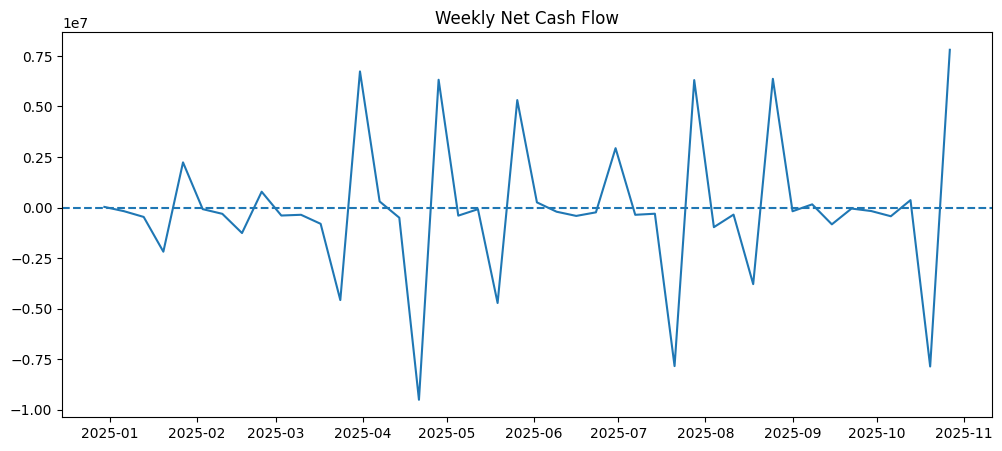

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(weekly_cash["Week"], weekly_cash["Net Cash"])
plt.axhline(0, linestyle="--")
plt.title("Weekly Net Cash Flow")
plt.show()


In [59]:
weekly_cash.describe()


,Week,Weekly Inflow,Weekly Outflow,Net Cash
count,44,44.00,44.00,44.00
mean,2025-05-29 12:00:00,"2,874,163.89","-2,963,214.45","-89,050.56"
min,2024-12-30 00:00:00,"78,930.06","-11,125,541.24","-9,510,155.21"
25%,2025-03-15 06:00:00,"618,695.44","-3,257,734.32","-578,142.14"
50%,2025-05-29 12:00:00,"1,009,923.43","-1,266,231.38","-271,296.14"
75%,2025-08-12 18:00:00,"4,657,731.28","-878,584.42","267,288.13"
max,2025-10-27 00:00:00,"10,287,893.98","-203,175.12","7,805,282.33"
std,NaN,"3,270,337.82","3,203,087.43","3,579,555.54"


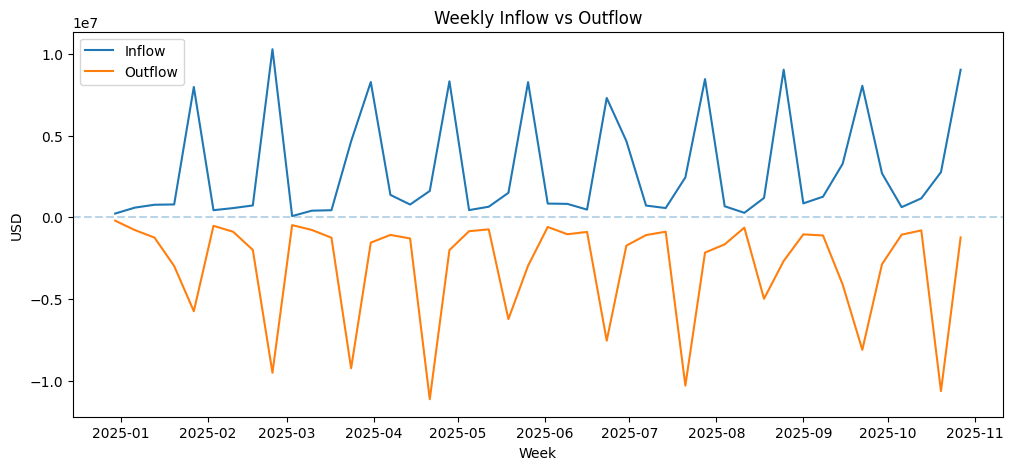

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(weekly_cash["Week"], weekly_cash["Weekly Inflow"], label="Inflow")
plt.plot(weekly_cash["Week"], weekly_cash["Weekly Outflow"], label="Outflow")
plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Weekly Inflow vs Outflow")
plt.xlabel("Week")
plt.ylabel("USD")
plt.show()


In [61]:
mean = weekly_cash["Net Cash"].mean()
std = weekly_cash["Net Cash"].std()

weekly_cash["Anomaly"] = (
    abs(weekly_cash["Net Cash"] - mean) > 2 * std
)

weekly_cash[weekly_cash["Anomaly"]]


,Week,Weekly Inflow,Weekly Outflow,Net Cash,Anomaly
16,2025-04-21,"1,615,386.03","-11,125,541.24","-9,510,155.21",True
29,2025-07-21,"2,448,043.65","-10,292,132.79","-7,844,089.14",True
42,2025-10-20,"2,767,467.17","-10,630,311.59","-7,862,844.43",True
43,2025-10-27,"9,031,625.33","-1,226,343.00","7,805,282.33",True


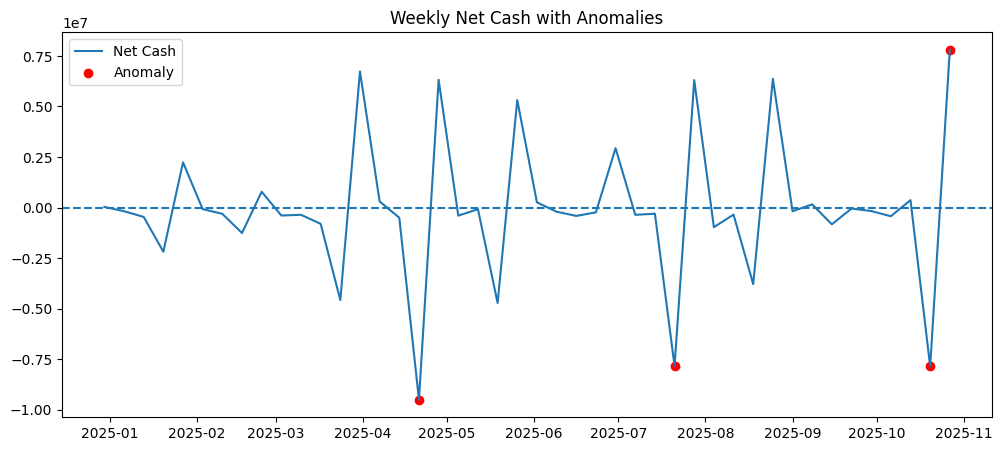

In [62]:
plt.figure(figsize=(12,5))
plt.plot(weekly_cash["Week"], weekly_cash["Net Cash"], label="Net Cash")
plt.scatter(
    weekly_cash.loc[weekly_cash["Anomaly"], "Week"],
    weekly_cash.loc[weekly_cash["Anomaly"], "Net Cash"],
    color="red",
    label="Anomaly"
)
plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Weekly Net Cash with Anomalies")
plt.show()


In [63]:
ts = weekly_cash.set_index("Week")["Net Cash"]

In [64]:
ts

,Net Cash
Week,
2024-12-30,"31,494.26"
2025-01-06,"-180,922.38"
2025-01-13,"-464,616.99"
2025-01-20,"-2,183,925.65"
2025-01-27,"2,234,934.38"
2025-02-03,"-78,044.23"
2025-02-10,"-311,012.00"
2025-02-17,"-1,261,535.60"
2025-02-24,"782,694.61"


#METHOD 1


In [65]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=5   # approx monthly cycle
)

fit = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [66]:
forecast_1m = fit.forecast(4)
forecast_1m


,0
2025-11-03,"638,764.03"
2025-11-10,"-1,325,431.62"
2025-11-17,"-1,338,180.99"
2025-11-24,"156,916.93"


In [67]:
forecast_6m = fit.forecast(24)


In [68]:
forecast_6m

,0
2025-11-03,"638,764.03"
2025-11-10,"-1,325,431.62"
2025-11-17,"-1,338,180.99"
2025-11-24,"156,916.93"
2025-12-01,"1,629,372.63"
2025-12-08,"637,121.06"
2025-12-15,"-1,327,074.59"
2025-12-22,"-1,339,823.96"
2025-12-29,"155,273.96"
2026-01-05,"1,627,729.66"


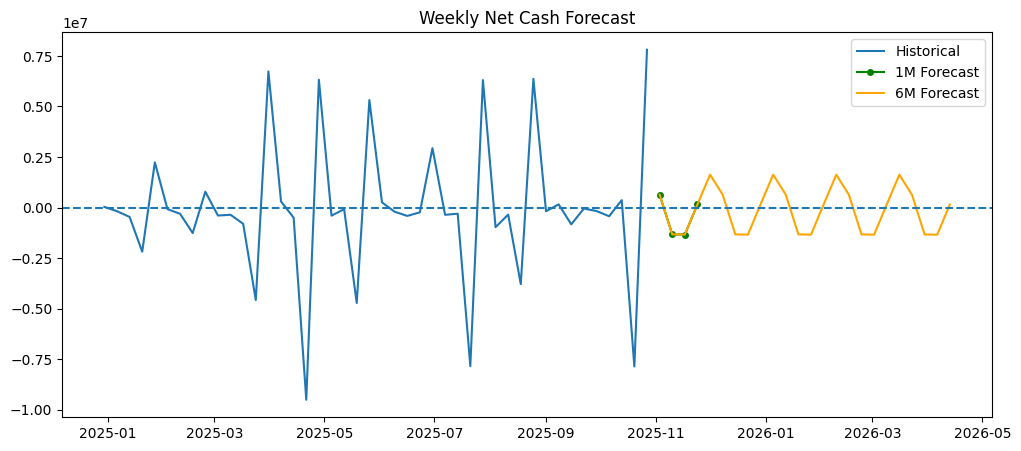

In [69]:
plt.figure(figsize=(12,5))
plt.plot(ts, label="Historical")
plt.plot(forecast_1m, label="1M Forecast", color="green", marker='o', markersize=4)
plt.plot(forecast_6m, label="6M Forecast", color="orange")
plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Weekly Net Cash Forecast")
plt.show()

In [70]:
# Choose test horizon
test_size = 8

train_ts = ts[:-test_size]
test_ts = ts[-test_size:]


In [71]:
pred = fit.forecast(len(test_ts))


In [72]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test_ts, pred)
mae


2575545.9605100136

In [73]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_ts, pred))
rmse


np.float64(4075979.486049778)

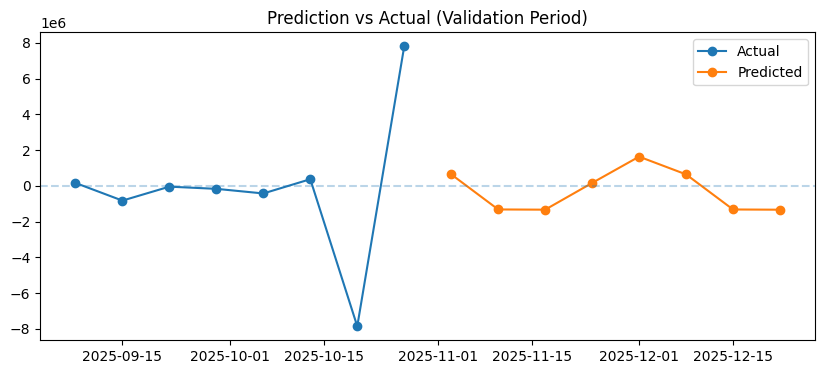

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(test_ts.index, test_ts.values, label="Actual", marker="o")
plt.plot(pred.index, pred.values, label="Predicted", marker="o")
plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Prediction vs Actual (Validation Period)")
plt.show()


#METHOD 2

In [75]:
model = ExponentialSmoothing(
    ts,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=4
)

fit = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


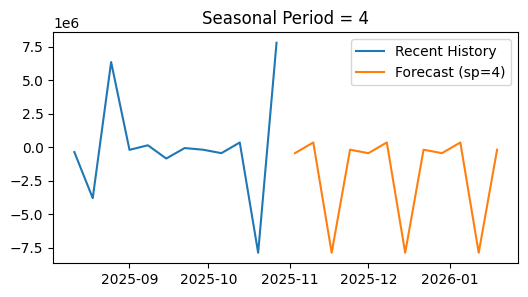

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


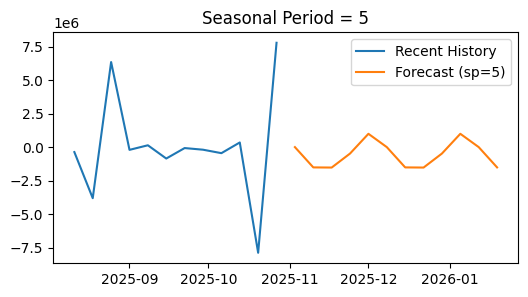

In [76]:
for sp in [4, 5]:
    model = ExponentialSmoothing(
        ts,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=sp
    )
    fit = model.fit()
    forecast = fit.forecast(12)

    plt.figure(figsize=(6,3))
    plt.plot(ts[-12:], label="Recent History")
    plt.plot(forecast, label=f"Forecast (sp={sp})")
    plt.title(f"Seasonal Period = {sp}")
    plt.legend()
    plt.show()


In [77]:
train = ts[:-12]
test  = ts[-12:]


In [78]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

results = {}

for sp in [4, 5]:
    model = ExponentialSmoothing(
        train,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=sp
    )
    fit = model.fit()
    forecast = fit.forecast(12)

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test)) * 100

    results[sp] = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

results


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


{4: {'MAE': 4086039.5740789077,
  'RMSE': np.float64(6063398.733746969),
  'MAPE (%)': np.float64(1392.2550938967474)},
 5: {'MAE': 2777720.9609115496,
  'RMSE': np.float64(3828278.1480050036),
  'MAPE (%)': np.float64(485.06385334330747)}}

#MODEL 3


In [79]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


In [80]:
ts_in = weekly_cash.set_index("Week")["Weekly Inflow"]
ts_out = weekly_cash.set_index("Week")["Weekly Outflow"]

In [81]:
train_in  = ts_in[:-12]
test_in   = ts_in[-12:]

train_out = ts_out[:-12]
test_out  = ts_out[-12:]


In [82]:
def evaluate_hw(train, test, sp):
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=sp
    ).fit()

    forecast = model.forecast(len(test))

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    return mae, rmse, forecast


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


SP=4
  Inflow  → MAE=1,845,697.00, RMSE=2,958,257.62
  Outflow → MAE=3,305,528.32, RMSE=4,766,346.94


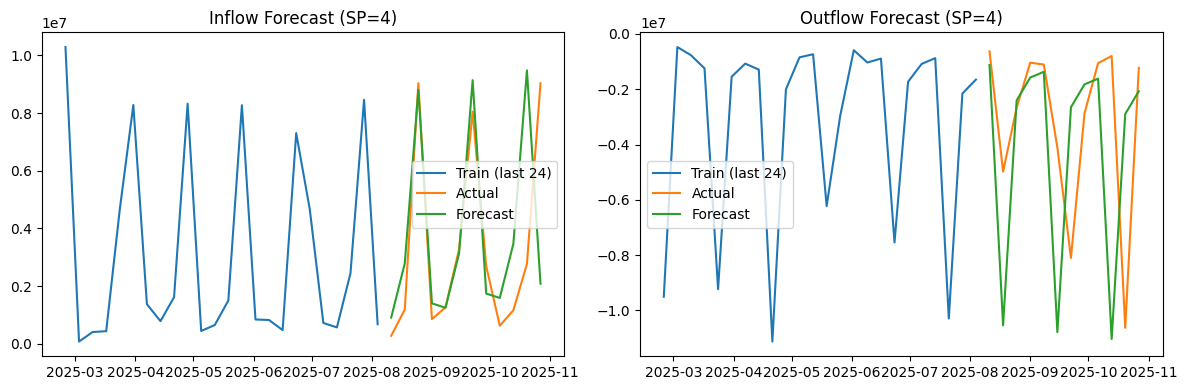

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


SP=5
  Inflow  → MAE=2,376,258.01, RMSE=2,866,370.76
  Outflow → MAE=2,429,447.75, RMSE=3,067,632.14


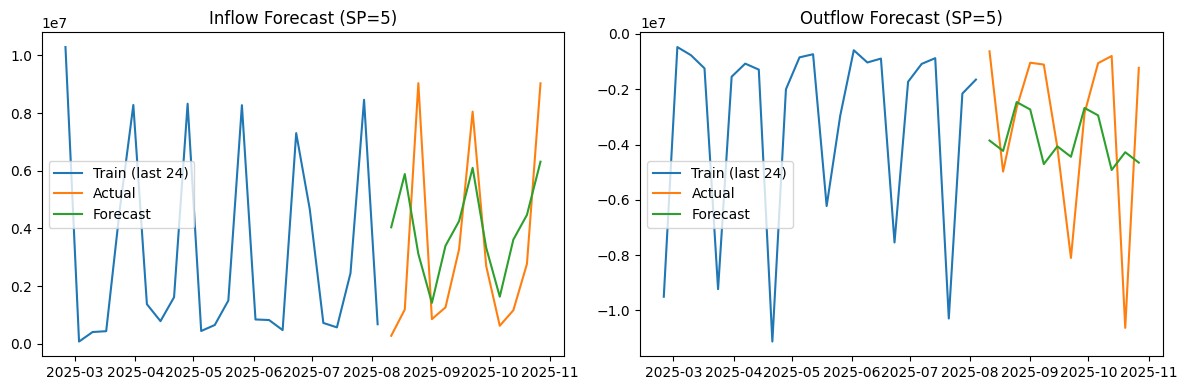

In [83]:
for sp in [4, 5]:
    mae_in, rmse_in, f_in = evaluate_hw(train_in, test_in, sp)
    mae_out, rmse_out, f_out = evaluate_hw(train_out, test_out, sp)

    print(f"SP={sp}")
    print(f"  Inflow  → MAE={mae_in:,.2f}, RMSE={rmse_in:,.2f}")
    print(f"  Outflow → MAE={mae_out:,.2f}, RMSE={rmse_out:,.2f}")

    # -------- PLOTS --------
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Inflow plot
    ax[0].plot(train_in[-24:], label="Train (last 24)")
    ax[0].plot(test_in, label="Actual")
    ax[0].plot(f_in, label="Forecast")
    ax[0].set_title(f"Inflow Forecast (SP={sp})")
    ax[0].legend()

    # Outflow plot
    ax[1].plot(train_out[-24:], label="Train (last 24)")
    ax[1].plot(test_out, label="Actual")
    ax[1].plot(f_out, label="Forecast")
    ax[1].set_title(f"Outflow Forecast (SP={sp})")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


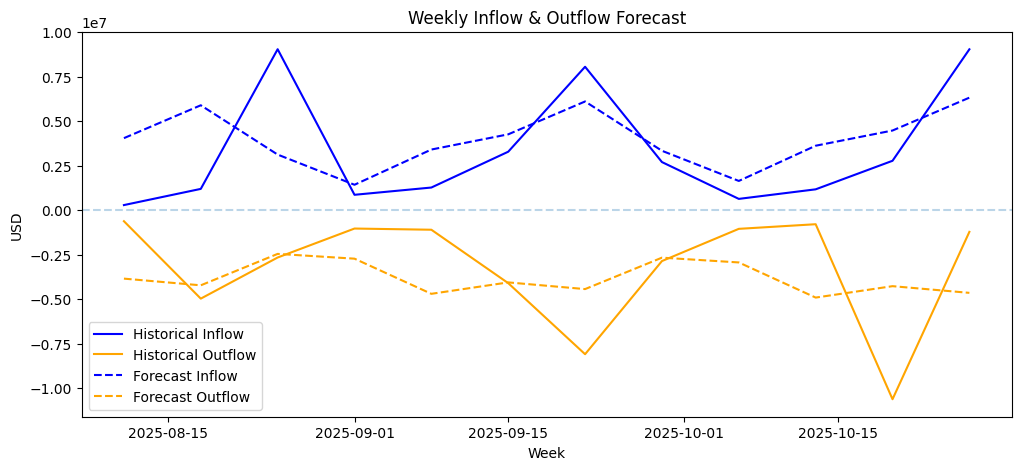

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Historical (last 12 weeks for clarity)
plt.plot(ts_in[-12:], label="Historical Inflow", color="blue")
plt.plot(ts_out[-12:], label="Historical Outflow", color="orange")

# Forecasts
plt.plot(f_in, label="Forecast Inflow", color="blue", linestyle="--")
plt.plot(f_out, label="Forecast Outflow", color="orange", linestyle="--")

plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Weekly Inflow & Outflow Forecast")
plt.xlabel("Week")
plt.ylabel("USD")
plt.show()


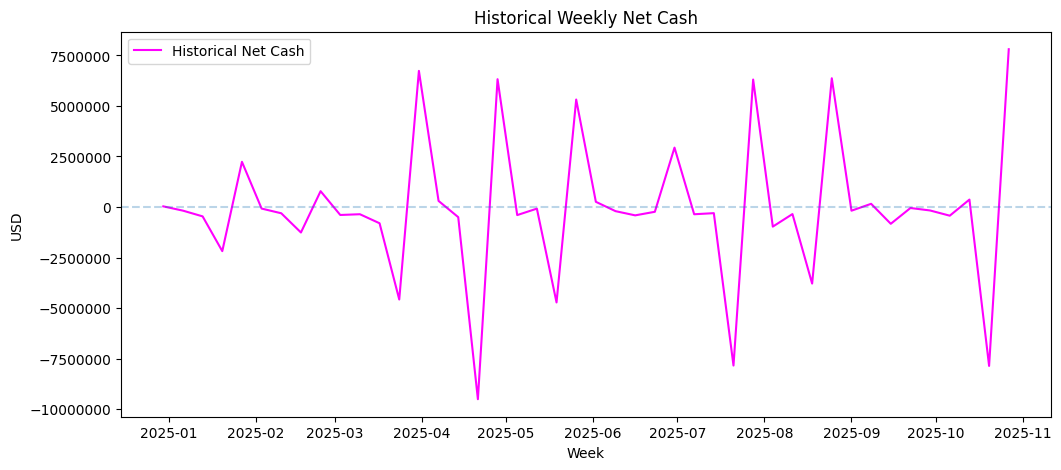

In [85]:
plt.figure(figsize=(12,5))

# Historical net cash
plt.plot(
    weekly_cash["Week"],
    weekly_cash["Net Cash"],
    label="Historical Net Cash",
    color="MAGENTA"
)

plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Historical Weekly Net Cash")
plt.xlabel("Week")
plt.ylabel("USD")
plt.ticklabel_format(style='plain', axis='y') # Added to remove scientific notation from y-axis
plt.show()

In [86]:
model_in = ExponentialSmoothing(
    ts_in, trend="add", seasonal="add", seasonal_periods=5
).fit()

model_out = ExponentialSmoothing(
    ts_out, trend="add", seasonal="add", seasonal_periods=5
).fit()
model_in = ExponentialSmoothing(
    ts_in, trend="add", seasonal="add", seasonal_periods=5
).fit()

model_out = ExponentialSmoothing(
    ts_out, trend="add", seasonal="add", seasonal_periods=5
).fit()

f_in = model_in.forecast(4)
f_out = model_out.forecast(4)

f_net = f_in + f_out

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [87]:
f_net

,0
2025-11-03,"640,900.92"
2025-11-10,"-1,319,783.69"
2025-11-17,"-1,313,788.60"
2025-11-24,"167,240.85"


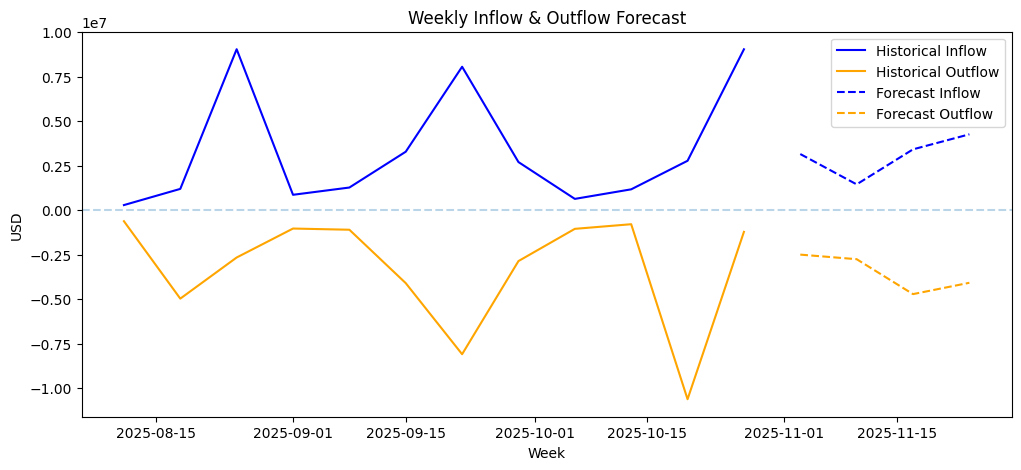

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Historical (last 12 weeks for clarity)
plt.plot(ts_in[-12:], label="Historical Inflow", color="blue")
plt.plot(ts_out[-12:], label="Historical Outflow", color="orange")

# Forecasts
plt.plot(f_in, label="Forecast Inflow", color="blue", linestyle="--")
plt.plot(f_out, label="Forecast Outflow", color="orange", linestyle="--")

plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Weekly Inflow & Outflow Forecast")
plt.xlabel("Week")
plt.ylabel("USD")
plt.show()


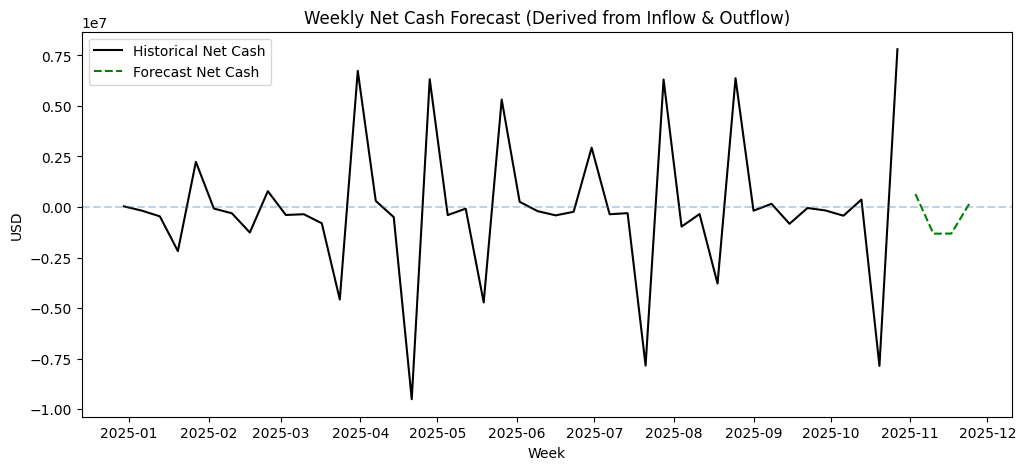

In [89]:
plt.figure(figsize=(12,5))

# Historical net cash
plt.plot(
    weekly_cash["Week"],
    weekly_cash["Net Cash"],
    label="Historical Net Cash",
    color="black"
)

# Forecast net cash
plt.plot(
    f_net.index,
    f_net.values,
    label="Forecast Net Cash",
    color="green",
    linestyle="--"
)

plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Weekly Net Cash Forecast (Derived from Inflow & Outflow)")
plt.xlabel("Week")
plt.ylabel("USD")
plt.show()


In [90]:
model_in = ExponentialSmoothing(
    ts_in, trend="add", seasonal="add", seasonal_periods=5
).fit()

model_out = ExponentialSmoothing(
    ts_out, trend="add", seasonal="add", seasonal_periods=5
).fit()
model_in = ExponentialSmoothing(
    ts_in, trend="add", seasonal="add", seasonal_periods=5
).fit()

model_out = ExponentialSmoothing(
    ts_out, trend="add", seasonal="add", seasonal_periods=5
).fit()

f_in = model_in.forecast(24)
f_out = model_out.forecast(24)

f_net = f_in + f_out

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [91]:
f_net

,0
2025-11-03,"640,900.92"
2025-11-10,"-1,319,783.69"
2025-11-17,"-1,313,788.60"
2025-11-24,"167,240.85"
2025-12-01,"1,646,519.75"
2025-12-08,"642,457.80"
2025-12-15,"-1,318,226.81"
2025-12-22,"-1,312,231.72"
2025-12-29,"168,797.73"
2026-01-05,"1,648,076.64"


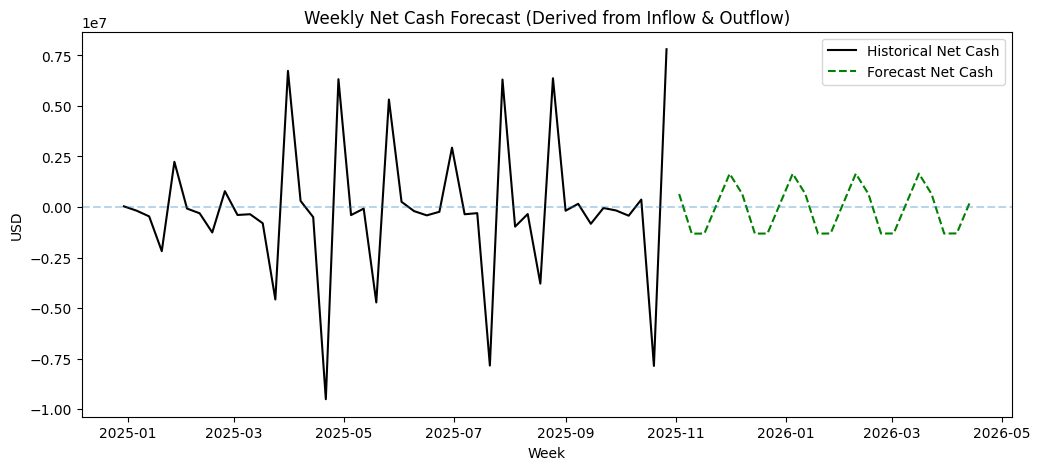

In [92]:
plt.figure(figsize=(12,5))

# Historical net cash
plt.plot(
    weekly_cash["Week"],
    weekly_cash["Net Cash"],
    label="Historical Net Cash",
    color="black"
)

# Forecast net cash
plt.plot(
    f_net.index,
    f_net.values,
    label="Forecast Net Cash",
    color="green",
    linestyle="--"
)

plt.axhline(0, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Weekly Net Cash Forecast (Derived from Inflow & Outflow)")
plt.xlabel("Week")
plt.ylabel("USD")
plt.show()
